# Decision Tree

В этом ноутбуке будут рассмотрены модели, основанные на технологии деревьев решений.

Деревья способные уловить нелинейные зависимости, от чего,предположительно, результат будет лучше, чем от линейной регрессии.

Содержание:
1. Загрузка данных
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. CatBoost
6. Сравнение моделей и анализ лучшей
7. Артефакты
8. Заключение

## 1. Загрузка данных

### 1.1. Импорты

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd
import os

random_state = 42
models_results = []

def evaluate(y_true: pd.Series, y_pred: pd.Series, name: str) -> tuple[float, float]:
    """
    Функция оценки. Считает и выводит rmse и mae.
    Параметры:
      y_true - серия с реальными оценками
      y_pred - серия с предсказанными оценками
      name - название датасета
    Возвращает:
      rmse - средне квадратическое отклонение
      mae - среднее абсолютное отклонение
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name}: RMSE = {rmse:.4f}, MAE = {mae:.4f}")

    return rmse, mae

### 1.2. Загрузка данных

In [2]:
data_path = os.path.join('..', 'data', 'ml-latest-small')

# Загружаем подготовленные датасеты
train = pd.read_csv(os.path.join(data_path, 'train.csv'))
val = pd.read_csv(os.path.join(data_path, 'val.csv'))
test = pd.read_csv(os.path.join(data_path, 'test.csv'))

print(f'train {train.shape}')
print(f'val {val.shape}')
print(f'test {test.shape}')

train (70584, 44)
val (10084, 44)
test (20168, 44)


### 1.3. Отделяем target

In [3]:
features = [col for col in train.columns if col not in ['rating', 'movieId', 'userId']]

X_train = train[features]
X_val = val[features]
X_test = test[features]

print("X_train min:", X_train.min(), "max:", X_train.max())
print("X_train mean:", X_train.mean(), "std:", X_train.std())

y_train = train['rating'].values
y_val = val['rating'].values
y_test = test['rating'].values

X_train min: timestamp               8.281246e+08
Action                  0.000000e+00
Adventure               0.000000e+00
Animation               0.000000e+00
Children                0.000000e+00
Comedy                  0.000000e+00
Crime                   0.000000e+00
Documentary             0.000000e+00
Drama                   0.000000e+00
Fantasy                 0.000000e+00
Film-Noir               0.000000e+00
Horror                  0.000000e+00
IMAX                    0.000000e+00
Musical                 0.000000e+00
Mystery                 0.000000e+00
Romance                 0.000000e+00
Sci-Fi                  0.000000e+00
Thriller                0.000000e+00
War                     0.000000e+00
Western                 0.000000e+00
movie_avg_rating        8.571429e-01
user_avg_rating         5.000000e-01
user_avg_Action         5.000000e-01
user_avg_Adventure      5.000000e-01
user_avg_Animation      5.000000e-01
user_avg_Children       5.000000e-01
user_avg_Comedy         5

## 2. Decision Tree

### 2.1. Импорты

In [4]:
from sklearn.tree import DecisionTreeRegressor

### 2.2. Обучение

In [5]:
def grid_search_custom(model_constructor, param_grid, X_train, y_train, X_val, y_val):
    """
    Рекурсивный перебор гиперпараметров
    Параметры:
        model_constructor - функция, создающая модель (например, lambda: DecisionTreeRegressor(random_state=42))
        param_grid - словарь с параметрами и списками значений
        X_train, y_train - обучающие данные
        X_val, y_val - валидационные данные
    Возвращает:
        best_params - словарь с лучшими параметрами
        best_score - лучшая метрика (RMSE)
        best_model - лучшая обученная модель
    """
    best_params = {}
    best_score = float('inf')
    best_model = None

    def _recursive_search(current_params, remaining_params):
        nonlocal best_params, best_score, best_model

        if not remaining_params:
            # Все параметры зафиксированы — обучаем модель
            model = model_constructor(**current_params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))

            if rmse < best_score:
                best_score = rmse
                best_params = current_params.copy()
                best_model = model

                print(f"{current_params} -> RMSE: {rmse:.4f}")

            return

        # Берем следующий параметр для перебора
        param_name, param_values = list(remaining_params.items())[0]
        remaining = {k: v for k, v in remaining_params.items() if k != param_name}

        for value in param_values:
            current_params[param_name] = value
            _recursive_search(current_params, remaining)

    _recursive_search({}, param_grid)

    return best_params, best_score, best_model

In [6]:
model_constructor = lambda **kwargs: DecisionTreeRegressor(random_state=42, **kwargs)

# Сетка параметров
param_grid = {
    'max_depth': [5, 7, 10, 15],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 50],
    'max_features': ['sqrt', None],
    'ccp_alpha': [0.0, 0.001, 0.005]
}

# Запускаем поиск
best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid,
    X_train, y_train,
    X_val, y_val
)

{'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'ccp_alpha': 0.0} -> RMSE: 1.0028
{'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'ccp_alpha': 0.0} -> RMSE: 0.9892
{'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'ccp_alpha': 0.001} -> RMSE: 0.9882
{'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'ccp_alpha': 0.0} -> RMSE: 0.9794
{'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 50, 'max_features': None, 'ccp_alpha': 0.0} -> RMSE: 0.9775


### 2.3. Оценка лучшей модели

In [7]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

print(best_params)

results = {
    'name': 'DecisionTreeRegressor',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'random_state': random_state
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)

Train: RMSE = 0.8941, MAE = 0.6949
Test: RMSE = 1.0214, MAE = 0.8121
{'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 50, 'max_features': None, 'ccp_alpha': 0.0}


## 3. Random Forest

Так как random forest основан на технологии ансамблей, то ответ нескольких деревьев будет более стабильным и может дать более лучшую оценку.

### 3.1. Импорты

In [8]:
from sklearn.ensemble import RandomForestRegressor

### 3.2. Обучение

In [9]:
model_constructor = lambda **kwargs: RandomForestRegressor(bootstrap=True, random_state=42, **kwargs)

# Сетка параметров
param_grid = {
    'n_estimators': [50, 100, 200, 500]
}
for param, value in best_params.items():
    param_grid[param] = [value]

# Запускаем поиск
best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid,
    X_train, y_train,
    X_val, y_val
)

{'n_estimators': 50, 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 50, 'max_features': None, 'ccp_alpha': 0.0} -> RMSE: 0.9691


### 3.3. Оценка лучшей модели

In [10]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

print(best_params)

results = {
    'name': 'RandomForestRegressor',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'random_state': random_state
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)

Train: RMSE = 0.8834, MAE = 0.6860
Test: RMSE = 1.0131, MAE = 0.7998
{'n_estimators': 50, 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 50, 'max_features': None, 'ccp_alpha': 0.0}


## 4. Gradient Boosting

Использует подход, где исправляет ошибки предыдущего дерева.

### 4.1. Импорты

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

### 4.2. Обучение

In [12]:
model_constructor = lambda **kwargs: GradientBoostingRegressor(random_state=42, **kwargs)

# Сетка параметров
param_grid = {
    'n_estimators': [500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.8, 1.0],
    'min_samples_split': [50],
    'min_samples_leaf': [20],
    'max_features': ['sqrt'],
    'ccp_alpha': [0.001],
    'validation_fraction': [0.1],
    'n_iter_no_change': [10],
    'tol': [1e-4]
}

# Запускаем поиск
best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid,
    X_train, y_train,
    X_val, y_val
)

{'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.8, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.001, 'validation_fraction': 0.1, 'n_iter_no_change': 10, 'tol': 0.0001} -> RMSE: 0.9739
{'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 1.0, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.001, 'validation_fraction': 0.1, 'n_iter_no_change': 10, 'tol': 0.0001} -> RMSE: 0.9734
{'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.001, 'validation_fraction': 0.1, 'n_iter_no_change': 10, 'tol': 0.0001} -> RMSE: 0.9722
{'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 10, 'subsample': 0.8, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.001, 'validation_fraction': 0.1, 'n_iter_no_change': 10, 'tol': 0.00

### 4.3. Оценка лучшей модели

In [13]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

print(best_params)

results = {
    'name': 'GradientBoostingRegressor',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'random_state': random_state
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)

Train: RMSE = 0.8953, MAE = 0.6976
Test: RMSE = 1.0129, MAE = 0.8027
{'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 10, 'subsample': 0.8, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.001, 'validation_fraction': 0.1, 'n_iter_no_change': 10, 'tol': 0.0001}


## 5. CatBoost

Решает некоторые проблемы градиентного бустинга: уменьшает переобучение и увеличивает скорость обучения

### 5.1. Импорты

In [14]:
from catboost import CatBoostRegressor

### 5.2. Обучение

In [15]:
model_constructor = lambda **kwargs: CatBoostRegressor(random_state=42, verbose=False, allow_writing_files=False, **kwargs)

param_grid = {
    'iterations': [500],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5],
    'bagging_temperature': [0.5, 1]
}

best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid,
    X_train, y_train,
    X_val, y_val
)

{'iterations': 500, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 1, 'bagging_temperature': 0.5} -> RMSE: 0.9709
{'iterations': 500, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 3, 'bagging_temperature': 0.5} -> RMSE: 0.9703
{'iterations': 500, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 5, 'bagging_temperature': 0.5} -> RMSE: 0.9702
{'iterations': 500, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 1, 'bagging_temperature': 0.5} -> RMSE: 0.9686
{'iterations': 500, 'learning_rate': 0.03, 'depth': 6, 'l2_leaf_reg': 3, 'bagging_temperature': 0.5} -> RMSE: 0.9678
{'iterations': 500, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 5, 'bagging_temperature': 0.5} -> RMSE: 0.9663


### 5.3. Оценка лучшей модели

In [16]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

print(best_params)

results = {
    'name': 'CatBoostRegressor',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'random_state': random_state
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)

best_y_test_pred = y_test_pred

Train: RMSE = 0.8389, MAE = 0.6507
Test: RMSE = 1.0104, MAE = 0.7939
{'iterations': 500, 'learning_rate': 0.03, 'depth': 8, 'l2_leaf_reg': 5, 'bagging_temperature': 0.5}


## 6. Сравнение моделей и анализ лучшей

### 6.1. Импорты

In [17]:
import matplotlib.pyplot as plt

### 6.2. Сравнение моделей

In [18]:
results_df = pd.DataFrame(models_results)
results_df

,name,train_rmse,train_mae,test_rmse,test_mae,random_state,max_depth,min_samples_split,min_samples_leaf,max_features,...,n_estimators,learning_rate,subsample,validation_fraction,n_iter_no_change,tol,iterations,depth,l2_leaf_reg,bagging_temperature
0,DecisionTreeRegressor,0.894124,0.694866,1.021434,0.812088,42,[7],[20],[50],[None],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RandomForestRegressor,0.883353,0.685996,1.013138,0.799841,42,[7],[20],[50],[None],...,[50],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GradientBoostingRegressor,0.895270,0.697609,1.012868,0.802669,42,[10],[50],[20],[sqrt],...,[500],[0.1],[0.8],[0.1],[10],[0.0001],NaN,NaN,NaN,NaN
3,CatBoostRegressor,0.838884,0.650718,1.010384,0.793933,42,NaN,NaN,NaN,NaN,...,NaN,[0.03],NaN,NaN,NaN,NaN,[500],[8],[5],[0.5]


### 6.3. Анализ лучшей модели

In [19]:
best_row = results_df.loc[results_df['test_rmse'].idxmin()]

best_params = best_row.to_dict()

for name, value in best_params.items():
    if isinstance(value, list):
        best_params[name] = value[0]
    else: 
        best_params[name] = value

best_params

{'name': 'CatBoostRegressor',
 'train_rmse': 0.8388843239784762,
 'train_mae': 0.6507175339013277,
 'test_rmse': 1.0103843848984475,
 'test_mae': 0.7939329261809729,
 'random_state': 42,
 'max_depth': nan,
 'min_samples_split': nan,
 'min_samples_leaf': nan,
 'max_features': nan,
 'ccp_alpha': nan,
 'n_estimators': nan,
 'learning_rate': 0.03,
 'subsample': nan,
 'validation_fraction': nan,
 'n_iter_no_change': nan,
 'tol': nan,
 'iterations': 500,
 'depth': 8,
 'l2_leaf_reg': 5,
 'bagging_temperature': 0.5}

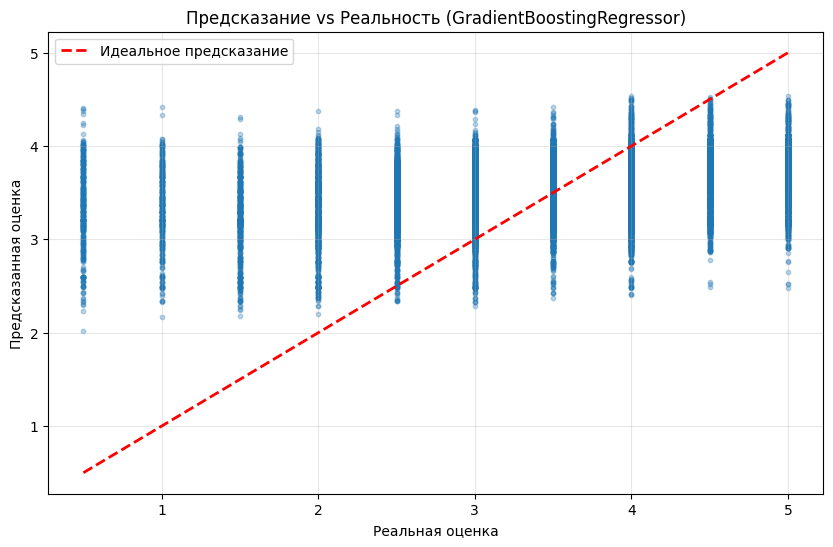

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test, best_y_test_pred, alpha=0.3, s=10)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
ax.set_xlabel('Реальная оценка')
ax.set_ylabel('Предсказанная оценка')
ax.set_title(f'Предсказание vs Реальность (GradientBoostingRegressor)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 7. Артефакты

In [ ]:
import json

artifacts_path = os.path.join('..', 'artifacts','experiments', 'exp03')
os.makedirs(artifacts_path, exist_ok=True)

results_df.to_csv(os.path.join(artifacts_path, 'runs.csv'), index=False)

with open(os.path.join(artifacts_path, 'best_model_params.json'), 'w') as f:
    json.dump(best_params, f, indent=4)

fig.savefig(os.path.join(artifacts_path, 'prediction_vs_actual.png'), dpi=150, bbox_inches='tight')

## 8. Заключение

По итогу эксперимента деревья также не смогли показать результата, сильно отличного от линейной регрессии. Поэтому данные модели также малопригодны для поставленной задачи.